
# GNN Tangency Portfolio - Time-Varying Correlation Graph Extension
### Replication of Liu, Li & Kang (2026), Neural Networks 193, 108043

# Library Imports

In [ ]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
!pip install torch_geometric
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# PyTorch Geometric - Graph Convolutional, Graph Attention, and GraphSAGE
from torch_geometric.nn import GCNConv, GATConv, SAGEConv


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.6 MB/s eta 0:00:00


# Data Description:

*   CSI - 300 data from 2001-01-01 to 2023-12-29 was obtained from the Chinese market data with 94 tickers from the below categories:




In [ ]:
TICKERS = [
    # ── FINANCIALS ──────────────────────────────────────────────────────────
    # Banks
    "600000.SS",   # Shanghai Pudong Development Bank
    "600015.SS",   # Hua Xia Bank
    "600016.SS",   # Minsheng Banking Corp
    "600036.SS",   # China Merchants Bank
    "000001.SZ",   # Ping An Bank

    # Securities & Diversified Financials
    "600030.SS",   # CITIC Securities
    "000166.SZ",   # Shenwan Hongyuan Group
    "000776.SZ",   # GF Securities
    "000783.SZ",   # Changjiang Securities

    # ── ENERGY ──────────────────────────────────────────────────────────────
    # Oil, Gas & Petrochemicals
    "600028.SS",   # China Petroleum & Chemical (Sinopec)
    "600688.SS",   # Shanghai Petrochemical
    "600426.SS",   # Qilu Petrochemical

    # Coal
    "600123.SS",   # Lanhua Sci-Tech
    "600348.SS",   # Shanxi Lu'an Environmental Energy
    "000877.SZ",   # Tianyuan Group

    # Power Generation
    "600900.SS",   # China Yangtze Power

    # ── MATERIALS ───────────────────────────────────────────────────────────
    # Steel & Iron
    "600010.SS",   # Inner Mongolia Baotou Steel
    "600019.SS",   # Baoshan Iron & Steel (Baosteel)
    "600022.SS",   # Shandong Iron and Steel
    "600516.SS",   # Dalian Fang Da Special Steel

    # Non-Ferrous Metals & Mining
    "600111.SS",   # China Northern Rare Earth Group
    "600219.SS",   # Shandong Nanshan Aluminium
    "600362.SS",   # Jiangxi Copper
    "600547.SS",   # Shandong Gold Mining
    "601600.SS",   # Aluminum Corporation of China (Chalco)

    # Chemicals
    "600096.SS",   # Yunnan Yuntianhua (phosphate chemicals)
    "600309.SS",   # Wanhua Chemical Group
    "000792.SZ",   # Qinghai Salt Lake Industry

    # Construction Materials
    "600585.SS",   # Anhui Conch Cement
    "000425.SZ",   # XCMG Construction Machinery  ← reclassified to Industrials below

    # ── INDUSTRIALS ─────────────────────────────────────────────────────────
    # Heavy Machinery & Equipment
    "600031.SS",   # Sany Heavy Industry
    "600150.SS",   # China CSSC Holdings (shipbuilding)
    "600320.SS",   # Shanghai Zhenhua Heavy Industries
    "000157.SZ",   # XCMG Group (Zhonglian Heavy Industry)
    "000425.SZ",   # XCMG Construction Machinery

    # Defence & Aerospace
    "600760.SS",   # AVIC Shenyang Aircraft
    "600893.SS",   # AVIC Aero-Engine Holdings
    "600428.SS",   # China Space Satellite (CASC)
    "000768.SZ",   # AVIC Aircraft Co.

    # Transportation & Logistics
    "600026.SS",   # COSCO Shipping Energy Transportation
    "600029.SS",   # China Southern Airlines
    "600033.SS",   # Fujian Expressway Development
    "600350.SS",   # Shandong Hi-Speed

    # Construction & Engineering
    "600170.SS",   # Shanghai Construction Group
    "601727.SS",   # Shanghai Electric Group

    # Power Equipment
    "600875.SS",   # Dongfang Electric

    # ── CONSUMER DISCRETIONARY ──────────────────────────────────────────────
    # Automobiles & Components
    "600006.SS",   # Dongfeng Motor Group
    "600104.SS",   # SAIC Motor Corporation
    "600741.SS",   # Huayu Automotive Systems
    "000625.SZ",   # Chongqing Changan Automobile

    # Household Appliances & Durables
    "000333.SZ",   # Midea Group
    "000651.SZ",   # Gree Electric Appliances
    "600690.SS",   # Haier Smart Home

    # Retail
    "600415.SS",   # Shanghai Bailian Group

    # Textiles & Apparel
    "600177.SS",   # Youngor Group

    # Leisure & Tourism
    "600158.SS",   # China Sports Industry Group
    "000069.SZ",   # Shenzhen Overseas Chinese Town (OCT)

    # Building Materials (Consumer-facing)
    "000786.SZ",   # Beijing New Building Materials (BNBM)

    # ── CONSUMER STAPLES ────────────────────────────────────────────────────
    # Baijiu & Spirits
    "600519.SS",   # Kweichow Moutai
    "600809.SS",   # Shanxi Xinghuacun Fen Wine
    "000568.SZ",   # Luzhou Laojiao
    "000596.SZ",   # Gujing Distillery
    "000858.SZ",   # Wuliangye Yibin

    # Food & Dairy
    "600887.SS",   # Inner Mongolia Yili Industrial Group
    "000895.SZ",   # Henan Shuanghui Investment (meat processing)

    # Household & Personal Products
    "600872.SS",   # Zhongshun Jierou (Vinda) tissue paper

    # ── HEALTH CARE ─────────────────────────────────────────────────────────
    # Pharmaceuticals (Western & TCM)
    "600276.SS",   # Jiangsu Hengrui Medicine
    "600535.SS",   # Tasly Pharmaceutical
    "600436.SS",   # Pien Tze Huang (TCM)
    "601607.SS",   # Shanghai Pharmaceuticals Holding
    "000876.SZ",   # Yunnan Baiyao Group (TCM)
    "000963.SZ",   # Huadong Medicine

    # Medical Devices & Biotech
    "000661.SZ",   # Changchun High & New Technology Industries

    # ── INFORMATION TECHNOLOGY ──────────────────────────────────────────────
    # Semiconductors & Electronic Components
    "600584.SS",   # Jiangsu Changjiang Electronics (JCET)
    "600703.SS",   # Sanan Optoelectronics
    "000725.SZ",   # BOE Technology Group (displays)
    "000938.SZ",   # Tsinghua Unigroup / Unis (semiconductor)

    # Software & IT Services
    "600570.SS",   # Hundsun Technologies (financial IT)
    "600588.SS",   # Yonyou Network Technology
    "000977.SZ",   # Inspur Electronic Information Industry

    # Technology Hardware & Infrastructure
    "600100.SS",   # Tsinghua Tongfang

    # ── COMMUNICATION SERVICES ──────────────────────────────────────────────
    # Telecom Equipment & Services
    "600050.SS",   # China United Network Communications (China Unicom)
    "000063.SZ",   # ZTE Corporation

    # Media & Entertainment
    "600637.SS",   # Orient Pearl Media (Dragon TV)

    # ── UTILITIES ───────────────────────────────────────────────────────────
    # Electric Utilities
    "600011.SS",   # Huaneng Power International
    "600027.SS",   # Huadian Power International
    "600795.SS",   # Datang International Power Generation

    # Water & Environmental Utilities
    "600008.SS",   # Capital Environment Holdings

    # ── REAL ESTATE ─────────────────────────────────────────────────────────
    # Property Development
    "600048.SS",   # Poly Developments and Holdings
    "600208.SS",   # Xinhu Zhongbao
    "600383.SS",   # Gemdale Corporation
    "600606.SS",   # Green Land Holdings
    "000002.SZ",   # China Vanke
    "001979.SZ"   # China Merchants Shekou Industrial Zone
]




# SECTION 1 - FEATURE ENGINEERING


*   7 features computed from raw OHLCV data only.


*   This dictionary contains all important fetaures in one place, this ensures the code is cleaner and updates are made at one place.


In [ ]:
CFG = {
    # --- GNN architecture: 'GCN', 'GAT', or 'SAGE'
    "gnn_type":   "GAT",

    # --- Graph construction method: 'pearson' or 'glasso'
    "graph_method": "pearson",

    # --- Edge threshold: stocks with |correlation| above this get an edge
    "threshold":  0.35,

    # --- Model dimensions ---
    "hidden_dim": 64,
    "embed_dim":  64,
    "num_layers": 2,
    "dropout":    0.1,
    "heads":      4,        # GAT only

    # --- Training ---
    "lr":         5e-3,     # paper: 5e-3
    "alpha1":     1e-3,     # modularity loss weight   (paper: 1e-3)
    "alpha2":     1e-1,     # ranking loss weight      (paper: 1e-1)
    "epochs":     100,
    "batch_size": 32,

    # --- Window sizes (paper: train=40, val=10) ---
    "train_len":  40,
    "val_len":    10,

    # --- Data ---
    "start":      "2001-01-01",
    "end":        "2023-12-29",
    "test_split": 0.15,     # fraction held out for final evaluation
    "seed":       42,
    "lr_warmup_epochs": 10,
}



*   This section transforms raw daily price and volume data into seven numerical signals that describe each stocks recent behaviour.
*   These signals are important imput features that the graph neural network uses to characterise each stock as a node



In [ ]:
def _rsi(prices, period=14):
    # Day-over-day price change;
    delta = np.diff(prices, prepend=prices[0])

    # Split changes into gains (up days) and losses (down days)
    gain = np.where(delta > 0, delta, 0.0)
    loss = np.where(delta < 0, -delta, 0.0)

    # Pre-allocate arrays for Wilder's smoothed averages
    avg_gain = np.full(len(prices), np.nan)
    avg_loss = np.full(len(prices), np.nan)

    # Not enough history - return neutral 0.0 for all days
    if len(prices) <= period:
        return np.full(len(prices), 0.0)

    # Seed: first smoothed average is a simple mean over the first period days
    avg_gain[period] = gain[1:period + 1].mean()
    avg_loss[period] = loss[1:period + 1].mean()

    # Wilder's exponential smoothing: new_avg = (old_avg*(period-1) + today) / period
    for i in range(period + 1, len(prices)):
        avg_gain[i] = (avg_gain[i - 1] * (period - 1) + gain[i]) / period
        avg_loss[i] = (avg_loss[i - 1] * (period - 1) + loss[i]) / period

    # RS = average gain / average loss; guard against division by zero
    rs  = avg_gain / np.where(avg_loss == 0, 1e-9, avg_loss)

    # Classic RSI formula: approaches 100 when all gains, 0 when all losses
    rsi = 100 - (100 / (1 + rs))

    # Fill the warmup period with neutral value (50 = no momentum)
    rsi[:period] = 50.0

    # Rescale from [0, 100] to [-1, 1] to match return feature scale
    return (rsi / 50.0) - 1.0


def _cross_section_zscore(x):
    """
    Z-score - This removes the market-wide level effect and leaves only relative signals.
    x : numpy array shape (T, N)
    returns: z-scored array shape (T, N)
    """
    # Mean and std across the N stocks dimension, one value per day
    mu    = x.mean(axis=1, keepdims=True)                  # (T, 1)
    sigma = x.std(axis=1,  keepdims=True).clip(min=1e-8)   # (T, 1)
    return (x - mu) / sigma


def build_features(close_df, volume_df):

    # Builds the (T, N, 7) feature tensor X from raw price and volume data.
    # This is H^0 -- the initial node features fed into the GNN.

    T, N = close_df.shape

    # Convert DataFrames to numpy float32 arrays
    close_np = close_df.values.astype(np.float32)
    vol_np   = volume_df.values.astype(np.float32)

    # --- Daily returns (T, N) ---
    # rets[0] = 0 (no previous day); rets[t] = close[t]/close[t-1] - 1
    rets = np.zeros_like(close_np)
    rets[1:] = close_np[1:] / close_np[:-1].clip(min=1e-9) - 1.0

    # Initialise the output feature tensor with zeros
    X = np.zeros((T, N, 7), dtype=np.float32)

    # --- Feature 0: 1-day return ---
    # Most direct short-term momentum signal
    X[:, :, 0] = rets

    # --- Feature 1: 5-day cumulative return ---
    # Captures the weekly trend that a single-day return misses
    for t in range(T):
        lo = max(0, t - 4)                                  # clamp to day 0
        X[t, :, 1] = close_np[t] / close_np[lo].clip(min=1e-9) - 1.0

    # --- Feature 2: 20-day cumulative return ---
    # ~1-month trend; standard short-term momentum look-back
    for t in range(T):
        lo = max(0, t - 19)
        X[t, :, 2] = close_np[t] / close_np[lo].clip(min=1e-9) - 1.0

    # --- Feature 3: 20-day realised volatility ---
    # std of daily returns over the past 20 days; measures recent risk
    for t in range(20, T):
        X[t, :, 3] = rets[t - 20:t].std(axis=0)
    # Backfill first 20 days with day-20 value (avoids NaN in warmup)
    X[:20, :, 3] = X[20, :, 3]

    # --- Feature 4: cross-sectional z-scored log volume ---
    # log1p compresses volume range; z-score removes market-wide level
    log_vol     = np.log1p(vol_np)
    X[:, :, 4]  = _cross_section_zscore(log_vol)

    # --- Feature 5: 60-day momentum (skip last 5 days) ---
    # Jegadeesh-Titman style: skip t-5 to t to avoid reversal noise
    for t in range(T):
        lo = max(0, t - 60)
        hi = max(0, t - 5)
        if hi > lo:
            X[t, :, 5] = close_np[hi] / close_np[lo].clip(min=1e-9) - 1.0

    # --- Feature 6: RSI(14) rescaled to [-1, 1] ---
    # Must loop over stocks; RSI uses a recursive formula per stock
    for n in range(N):
        X[:, n, 6] = _rsi(close_np[:, n], period=14)

    # --- Outlier clipping (5 cross-sectional std) ---
    # Prevents data errors / circuit-breaker events from dominating gradients
    for f in range(7):
        plane = X[:, :, f]
        mu    = plane.mean(axis=1, keepdims=True)
        sig   = plane.std(axis=1,  keepdims=True).clip(min=1e-8)
        X[:, :, f] = np.clip(plane, mu - 5 * sig, mu + 5 * sig)

    return X


   #### Produces sliding-window samples that match Table 2 of the paper.

    Each __getitem__(idx) returns a tuple of four tensors:
        x_feat   (train_len, N, 7) - feature window fed into GNN
        raw_ret  (train_len, N)    - raw returns over window (graph building)
        y_ret    (val_len,   N)    - forward returns (loss target)
        hist_ret (N,)              - mean return over window (ranking loss)

  *   Custom collate function for the DataLoader. Stacks all four tensors across the batch dimension.
*   We don't include edge_index in the batch because each sample has a different number of edges (E varies per window). The graph is looked up separately by window index during training.

In [ ]:
class SlidingWindowDataset(Dataset):

    def __init__(self, feature_tensor, return_tensor,
                 train_len=40, val_len=10):
        super().__init__()
        # Convert numpy arrays to float32 tensors stored in CPU RAM
        self.X  = torch.from_numpy(feature_tensor).float()
        self.R  = torch.from_numpy(return_tensor).float()
        self.tl = train_len
        self.vl = val_len
        T = feature_tensor.shape[0]
        # Number of valid non-overlapping-endpoint windows
        # e.g. T=2200, tl=40, vl=10 -> 2151 samples
        self.n_samples = T - train_len - val_len + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Feature window for the 40-day training period
        x_feat  = self.X[idx : idx + self.tl]              # (40, N, 7)

        # Return window used to build the rolling correlation graph
        raw_ret = self.R[idx : idx + self.tl]              # (40, N)

        # Forward return window -- what the portfolio must earn
        y_ret   = self.R[idx + self.tl : idx + self.tl + self.vl]  # (10, N)

        # Mean historical return per stock -- ranking loss target
        hist_ret = raw_ret.mean(dim=0)                      # (N,)

        return x_feat, raw_ret, y_ret, hist_ret


def collate_fn(batch):
    x_feats, raw_rets, y_rets, hist_rets = zip(*batch)
    return (torch.stack(x_feats),    # (B, 40, N, 7)
            torch.stack(raw_rets),   # (B, 40, N)
            torch.stack(y_rets),     # (B, 10, N)
            torch.stack(hist_rets))  # (B, N)


# SECTION 3 - GRAPH BUILDER (time-varying adjacency)


*   The key extension from the paper: instead of a fixed industry-chain graph, we rebuild the adjacency from rolling return correlations at every window position. This gives a new edge_index every day.
*   The second function, precompute_graphs, runs the process for every window position across the full dataset and stores all the resulting graphs in memory before training begins. Without pre-building, the model would need to recompute thousands of correlation matrices at every training epoch, which would be far too slow. By doing it once upfront the training loop can simply look up the right graph by index.



In [ ]:
def build_rolling_graph(returns_window, threshold=0.35,
                        method="pearson", min_edges=1):
    N = returns_window.shape[1]  # number of stocks

    if method == "pearson":
        # np.corrcoef expects variables as ROWS, so we transpose (T,N) -> (N,T)
        corr = np.corrcoef(returns_window.T)    # (N, N)

        # Replace NaN (occurs when a stock has zero variance - e.g. suspended)
        corr = np.nan_to_num(corr, nan=0.0)

        # Binary adjacency: 1 where |correlation| exceeds threshold
        adj  = (np.abs(corr) > threshold).astype(np.float32)

        # Remove self-loops -- each stock is trivially correlated with itself
        np.fill_diagonal(adj, 0)

    elif method == "glasso":
        # Graphical LASSO estimates the precision matrix (inverse covariance)
        # with an L1 penalty that forces many entries to exactly zero.
        # Sparser and more principled than Pearson thresholding but ~50x slower.
        try:
            from sklearn.covariance import GraphicalLassoCV
            gl = GraphicalLassoCV(cv=3, max_iter=500, assume_centered=False)
            gl.fit(returns_window)
            prec = gl.precision_                # (N, N) precision matrix
        except Exception:
            # Fallback to Pearson if LASSO fails (e.g. singular covariance)
            corr = np.corrcoef(returns_window.T)
            corr = np.nan_to_num(corr, nan=0.0)
            prec = corr
        adj = (np.abs(prec) > threshold).astype(np.float32)
        np.fill_diagonal(adj, 0)

    else:
        raise ValueError(f"Unknown graph method: {method}. Use 'pearson' or 'glasso'.")

    # Symmetrise: ensure if (i,j) is an edge then (j,i) is too
    # (after thresholding a precision matrix the two directions may differ)
    adj = np.maximum(adj, adj.T)

    # Safety fallback: if graph is too sparse, connect each stock to
    # its single most-correlated neighbour to prevent isolated nodes.
    # GNNs cannot aggregate from stocks with no neighbours.
    if adj.sum() < min_edges * 2:
        corr_fb = np.corrcoef(returns_window.T)
        corr_fb = np.nan_to_num(corr_fb, nan=0.0)
        np.fill_diagonal(corr_fb, -np.inf)      # exclude self
        best = np.argmax(np.abs(corr_fb), axis=1)  # best neighbour per stock
        for i, j in enumerate(best):
            adj[i, j] = 1.0
            adj[j, i] = 1.0

    # Convert adjacency matrix to edge_index format:
    # src[k], dst[k] are the source and destination of edge k
    src, dst = np.where(adj > 0)

    # PyG requires dtype=torch.long (int64) for node indices
    edge_index = torch.tensor(
        np.stack([src, dst], axis=0), dtype=torch.long)

    return edge_index   # shape (2, E)


def precompute_graphs(return_tensor, train_len=40,
                      threshold=0.35, method="pearson"):
    T = return_tensor.shape[0]
    n_windows = T - train_len + 1   # one graph per window position
    graphs = []

    print(f"  Building {n_windows} rolling graphs "
          f"(method={method}, threshold={threshold})...")

    for idx in range(n_windows):
        # Slice the 40-day return window for this position
        window = return_tensor[idx : idx + train_len]   # (40, N)
        ei = build_rolling_graph(window, threshold, method)
        graphs.append(ei)

        # Progress update every 200 windows
        if (idx + 1) % 200 == 0:
            print(f"    {idx+1}/{n_windows} graphs built", flush=True)

    print(f"  Done. Average edges per graph: "
          f"{np.mean([g.shape[1] for g in graphs]):.1f}")
    return graphs

# SECTION 4 - GNN EMBEDDING MODULE
*   This section defines the graph neural network that processes the stock graph and produces a numerical description of each stock's position within it. The key idea is message passing — each stock updates its own representation by gathering and summarising information from its connected neighbours, then passing the result on.
*   Implements Equation (4) from the paper: H^l = GNN(A, H^{l-1}; W^l),   H^0 = X,   l = 1,...,L

*   Supports GCN, GAT, and SAGE - all produce the same output shape (N, embed_dim) so the downstream fitter and loss functions are identical for all three.
* The key difference between architectures:
  * GCN  - treats all edges equally (fixed spectral normalisation)
  * GAT  - learns attention weights per edge (best for noisy corr graphs)
  * SAGE - ignores edge weights, samples and averages neighbours



In [ ]:
class GNNEmbedding(nn.Module):

    def __init__(self, in_dim=7, hidden_dim=64, out_dim=64,
                 num_layers=2, gnn_type="GAT",
                 dropout=0.1, heads=4):
        super().__init__()
        self.gnn_type   = gnn_type
        self.num_layers = num_layers
        self.dropout    = dropout

        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()   # one LayerNorm per layer

        for i in range(num_layers):
            d_in  = dims[i]
            d_out = dims[i + 1]

            if gnn_type == "GCN":
                # All neighbours get equal weight after degree normalisation
                self.convs.append(GCNConv(d_in, d_out, improved=False))

            elif gnn_type == "GAT":
                # Hidden layers use multiple heads (concatenated)
                h      = heads if i < num_layers - 1 else 1
                concat = (i < num_layers - 1)   # concat=True for hidden, False for last
                self.convs.append(
                    GATConv(d_in, d_out, heads=h,
                            concat=concat, dropout=dropout))
                if concat:
                    dims[i + 1] = d_out * h

            elif gnn_type == "SAGE":
                # Robust against noisy correlation graphs.
                self.convs.append(SAGEConv(d_in, d_out, aggr="mean"))

            else:
                raise ValueError(f"Unknown gnn_type '{gnn_type}'. "
                                 f"Use 'GCN', 'GAT', or 'SAGE'.")

            # LayerNorm normalises across the feature dimension per node
            # Prevents exploding/vanishing activations in deep GNNs
            self.norms.append(nn.LayerNorm(dims[i + 1]))


        final_dim = dims[num_layers]
        self.proj = (nn.Linear(final_dim, out_dim)
                     if final_dim != out_dim else nn.Identity())

    def forward(self, x, edge_index):
        # Each iteration is one message-passing round (one layer l)
        for conv, norm in zip(self.convs, self.norms):
            # Graph convolution: aggregate neighbour features
            x = conv(x, edge_index)     # (N, d_out)

            # Layer normalisation: rescale to zero mean, unit std per node
            x = norm(x)

            # Non-linearity: without this, all layers collapse to one linear map
            x = F.relu(x)

            # Dropout: randomly zero p fraction of activations during training
            # training=self.training ensures dropout is OFF during eval()
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Final projection (Identity if dimensions already match)
        return self.proj(x)             # (N, out_dim)


# SECTION 5 - MEAN & PRECISION FITTING LAYER

Once each stock has a 64-dimensional embedding from the GNN, this module converts those embeddings into the two quantities needed to construct a tangency portfolio: an estimate of each stock's expected return, and an estimate of how the stocks' returns co-vary with one another.
*   Implements Equations (5) and (6):
*   (5) mu_hat  = H^L * theta           - predicted expected returns
*   (6) prec_hat = ReLU(H^L*W) * ReLU(H^L*W)^T  - estimated inverse covariance matrix
*   Writing prec_hat = H_tilde @ H_tilde.T guarantees it is positive semi-definite without any constrained optimisation.

In [ ]:
class MeanPrecisionFitter(nn.Module):

    def __init__(self, embed_dim, n_stocks, rank=None):
        super().__init__()
        # Default to full-rank precision matrix
        self.rank = rank if rank is not None else n_stocks

        # theta: weight vector that maps each stock's embedding to a scalar
        # No bias - returns are centered around zero
        self.theta = nn.Linear(embed_dim, 1, bias=False)

        # W: projects embeddings into a rank-dimensional intermediate space
        # The outer product H_tilde @ H_tilde.T is always PSD
        self.W = nn.Linear(embed_dim, self.rank, bias=False)

    def forward(self, H):

        mu_hat = self.theta(H).squeeze(-1)          # (N,)
        # Equation (6): ReLU ensures H_tilde >= 0 everywhere
        # This is required because modularity loss needs non-negative adj
        H_tilde  = F.relu(self.W(H))               # (N, rank)

        # Outer product: always produces a symmetric PSD matrix
        # No eigenvalue constraints needed - it's mathematically guaranteed
        prec_hat = H_tilde @ H_tilde.t()           # (N, N)

        return mu_hat, prec_hat

# SECTION 6 - PORTFOLIO WEIGHT PREDICTION
This function combines the estimated expected return for each stock and the covariance between the stocks into the final portfolio weights using the tangency portfolio formula from the main paper.
*   Implements Equations (3) and (7):

*   (3) w_raw = Sigma^{-1} * mu^          -- tangency direction
*   (7) w = softmax(w+) - softmax(w-)     -- long-short weights
*   Stocks with high expected return AND low covariance with others get the largest positive weights
*   Clamp w_raw to prevent extremely large values when passed to torch.exp. This helps in numerical stability, especially during initial training,preventing NaNs from appearing in the loss. A range like [-5, 5] ensures exp arguments for 'a2 * w_raw' are within [-40, 40], which is generally stable.
    

In [ ]:
def predict_weights(mu_hat, prec_hat, a1=50.0, a2=8.0):

    w_raw = prec_hat @ mu_hat
    w_raw = torch.clamp(w_raw, min=-5.0, max=5.0)

    # Equation (7): convert raw weights to long-short via softmax sort
    # w_plus concentrates weight on high-signal stocks (long leg)
    w_plus  = -a1 * torch.exp(-a2 * w_raw)

    # w_minus concentrates weight on low-signal stocks (short leg)
    w_minus = -a1 * torch.exp( a2 * w_raw)

    # Long leg sums to 1, short leg sums to 1, net weight sum ~ 0
    # This creates a dollar-neutral portfolio (no net market exposure)
    w = F.softmax(w_plus,  dim=0) - F.softmax(w_minus, dim=0)

    return w

# SECTION 7 - LOSS FUNCTIONS
 This is the primary objective — to calculate the maximum Sharpe Ratio. After the model constructs a portfolio, its returns are calculated over the following 10 trading days.

  The Sharpe ratio of those returns is then computed: the average daily return above the risk-free rate, divided by the day-to-day variability of those returns.
  
   A high Sharpe ratio means the portfolio is generating consistent returns without excessive fluctuation, which is the goal   

*   Implements Equation (16): L = exp(-SR) + alpha1*modu + alpha2 * ranking

Three components:
*   exp(-SR)   - maximise Sharpe ratio (main objective)
*   modu       - regularise covariance to have block/cluster structure
*   ranking    - align expected predictions with historical return ranks



In [ ]:
def sharpe_loss(portfolio_returns, rf=0.0):

    excess = portfolio_returns - rf

    mean_r = excess.mean()
    # clamp prevents division by zero if all returns are identical early in training
    std_r  = excess.std().clamp(min=1e-6)

    sr = mean_r / std_r                      # daily Sharpe ratio

    # exp(-SR): large when SR is negative (bad), small when SR is positive (good)
    return torch.exp(-sr)


def modularity_loss(prec_hat):

    # Soft cluster assignment: softmax over each row of precision matrix
    # C[i,j] = probability that stock i belongs to cluster j
    C = F.softmax(prec_hat, dim=-1)                 # (N, N)

    # Degree vector: k[i] = sum of row i (weighted degree in precision graph)
    k    = prec_hat.sum(dim=1)                      # (N,)

    # 2m: total edge weight in the precision graph (used for normalisation)
    norm = k.sum().clamp(min=1e-8)

    # Modularity matrix K = Sigma^{-1} - k k^T / (2m)
    # K[i,j] > 0 means stocks i,j are more connected than a random null model
    K    = prec_hat - torch.outer(k, k) / norm      # (N, N)

    # Trace(C^T K C): measures how well cluster assignments C align with K
    # Higher trace = better-defined cluster structure
    modu = torch.trace(C.t() @ K @ C)

    # L1 norm: differentiable proxy for the L0 norm (count of non-zeros)
    # Used to normalise modularity so it doesn't grow with matrix scale
    l1   = prec_hat.abs().sum().clamp(min=1e-8)

    return modu / (2.0 * l1)


def ranking_loss(mu_hat, historical_rets, tau=0.01, max_pairs=5000):
    rank_order = historical_rets.argsort().argsort().float()

    # Build all pairs (i, j) where stock i has a LOWER historical rank than j
    # Broadcasting: (N,1) < (1,N) produces an N x N boolean matrix
    i_idx, j_idx = torch.where(
        rank_order.unsqueeze(1) < rank_order.unsqueeze(0))

    # Guard: no pairs found (can happen if all returns are identical)
    if len(i_idx) == 0:
        return torch.tensor(0.0, device=mu_hat.device)

    # Randomly subsample pairs to keep computation tractable
    # For N=50 stocks: N^2/2 ~ 1250 pairs -- fine without subsampling
    # For N=2912 stocks: ~8.5M pairs -- must subsample
    if len(i_idx) > max_pairs:
        perm  = torch.randperm(len(i_idx), device=mu_hat.device)
        i_idx = i_idx[perm[:max_pairs]]
        j_idx = j_idx[perm[:max_pairs]]

    # For each pair: diff = mu_hat[j] - mu_hat[i]
    # We want diff > 0 (model correctly ranks j above i)
    diff = mu_hat[j_idx] - mu_hat[i_idx]

    # Hinge loss: max(0, tau - diff)
    # Zero penalty when diff > tau (correctly ordered with margin)
    # Positive penalty when diff < tau (wrong order or insufficient margin)
    return F.relu(tau - diff).mean()


def total_loss(portfolio_returns, prec_hat, mu_hat,
               historical_rets, alpha1=1e-3, alpha2=1e-1, rf=0.0):

    l_sharpe  = sharpe_loss(portfolio_returns, rf)
    l_modu    = modularity_loss(prec_hat)
    l_ranking = ranking_loss(mu_hat, historical_rets)

    total = l_sharpe + alpha1 * l_modu + alpha2 * l_ranking

    components = {
        "sharpe":  l_sharpe.item(),
        "modu":    l_modu.item(),
        "ranking": l_ranking.item(),
        "total":   total.item(),
    }
    return total, components


# SECTION 8 - DATA DOWNLOAD

*   This function obtains the raw price and volume data needed to run the model. It downloads each stock individually from Yahoo Finance rather than in bulk, which is slower but more robust — if a single ticker fails or has insufficient history (fewer than 200 trading days), it is simply skipped rather than causing the entire download to fail.


In [ ]:

def load_or_download(ticker_list, start, end, cache_path="/content/prices.csv"):
    """
    Returns (close_df, volume_df) -- aligned DataFrames of shape (T, N).
    Loads from cache if it exists, otherwise downloads via yfinance.
    """
    close_list, vol_list, valid = [], [], []
    for tk in ticker_list:
        try:
            raw = yf.download(tk, start=start, end=end,
                              auto_adjust=True)
            if len(raw) < 200:
                continue
            # For newer yfinance, columns may be MultiIndex -- flatten
            close_col = raw["Close"] if "Close" in raw.columns else raw.iloc[:, 0]
            vol_col   = raw["Volume"] if "Volume" in raw.columns else raw.iloc[:, 4]
            close_col.name=tk
            close_list.append(close_col)
            vol_col.rename= tk
            vol_list.append(vol_col)
            valid.append(tk)
        except Exception as e:
            print(f"  Skipping {tk}: {e}")
            continue

    if not close_list:
        raise RuntimeError("No tickers downloaded successfully.")

    # Concatenate close and volume data
    full_close_df  = pd.concat(close_list, axis=1)
    full_volume_df = pd.concat(vol_list,   axis=1)

    # --- Process close_df: Drop entirely empty stock columns, ffill, bfill, then drop any remaining rows with NaNs ---
    # Drop columns (tickers) that are entirely NaN (no data for the whole period)
    close_df = full_close_df.dropna(axis=1, how='all')
    # Forward fill then backward fill to handle internal NaNs
    close_df = close_df.ffill().bfill()
    # Drop any rows that still contain NaNs (e.g., if a stock was not present for the initial period and bfill couldn't fill)
    close_df = close_df.dropna()

    # --- Process volume_df: Align to the cleaned close_df index and fill remaining NaNs with 0 ---
    # Align volume_df to the cleaned close_df index and columns
    volume_df = full_volume_df.reindex(index=close_df.index, columns=close_df.columns).fillna(0)

    # Cache to disk
    combined = pd.concat([close_df, volume_df], axis=1)
    combined.to_csv(cache_path)
    print(f"Saved {len(close_df)} days x {len(valid)} stocks to {cache_path}")
    return close_df, volume_df

# SECTION 9 - EVALUATION HELPERS

*   These two functions handle evaluating the trained model on data it has never seen during training.

* Returns:
  * all_port_rets  : list of daily portfolio returns (floats)
  * all_bench_rets : list of equal-weight benchmark returns (floats)
  * last_weights   : final window's portfolio weights (numpy array)
  * edge_densities : graph edge density per window

* Computes the standard portfolio metrics reported in Table 3 of the paper
  * rets         : list or array of daily portfolio returns
  * label        : string label for printing
  * trading_days : annualisation factor (252 for equities)



In [ ]:
def run_inference(gnn_model, fitter, loader, graphs, device, batch_size):

    gnn_model.eval()
    fitter.eval()
    all_port_rets  = []
    all_bench_rets = []
    edge_densities = []
    last_weights   = None

    with torch.no_grad():
        for batch_idx, (x_feat, raw_ret, y_ret, hist_ret) in enumerate(loader):
            x_feat = x_feat.to(device)
            y_ret  = y_ret.to(device)
            N      = x_feat.shape[2]
            B      = x_feat.shape[0]

            for b in range(B):
                # Average feature window over time: (40, N, 7) -> (N, 7)
                x_mean = x_feat[b].mean(dim=0)

                # Get the pre-built graph for this window position
                win_idx = (batch_idx * batch_size + b) % len(graphs)
                ei      = graphs[win_idx].to(device)

                # Track graph density (edges / possible edges)
                density = ei.shape[1] / max(N * (N - 1), 1)
                edge_densities.append(density)

                # Forward pass
                H                = gnn_model(x_mean, ei)       # (N, 64)
                mu_hat, prec_hat = fitter(H)                    # (N,), (N,N)
                w                = predict_weights(mu_hat, prec_hat)  # (N,)

                # Portfolio return over the 10-day forward window
                port_rets  = (y_ret[b] @ w).cpu().tolist()     # (10,)
                bench_rets = y_ret[b].mean(dim=-1).cpu().tolist()  # (10,)

                all_port_rets.extend(port_rets)
                all_bench_rets.extend(bench_rets)
                last_weights = w.cpu().numpy()

    return all_port_rets, all_bench_rets, last_weights, edge_densities


def compute_metrics(rets, label, trading_days=252):

    rets   = np.array(rets)
    mean_r = rets.mean()
    std_r  = rets.std() + 1e-8

    # Daily Sharpe * sqrt(252) = annualised Sharpe
    sr      = mean_r / std_r * trading_days ** 0.5
    ann_ret = mean_r * trading_days
    ann_vol = std_r  * trading_days ** 0.5

    # Maximum drawdown: largest peak-to-trough decline in cumulative returns
    cum  = np.cumprod(1 + rets)
    peak = np.maximum.accumulate(cum)
    mdd  = ((cum - peak) / peak).min()

    # Calmar ratio: annualised return divided by absolute max drawdown
    calmar   = ann_ret / abs(mdd) if mdd != 0 else 0.0
    win_rate = (rets > 0).mean()

    print(f"\n  [{label}]")
    print(f"  Sharpe Ratio (annual) : {sr:.4f}")
    print(f"  Return (annual)       : {ann_ret:.4f}")
    print(f"  Volatility (annual)   : {ann_vol:.4f}")
    print(f"  Max Drawdown          : {mdd:.4f}")
    print(f"  Calmar Ratio          : {calmar:.4f}")
    print(f"  Win Rate              : {win_rate:.4f}")

    return {
        "Sharpe (annual)":   round(sr, 4),
        "Return (annual)":   round(ann_ret, 4),
        "Volatility (ann)":  round(ann_vol, 4),
        "Max Drawdown":      round(mdd, 4),
        "Calmar Ratio":      round(calmar, 4),
        "Win Rate":          round(win_rate, 4),
    }, cum



# SECTION 10 - DIAGNOSTIC PLOTS
    Produces a 6-panel diagnostic figure:
        1. Training loss components over epochs
        2. Validation Sharpe ratio over epochs
        3. Cumulative return (portfolio vs equal-weight benchmark)
        4. Drawdown over the test period
        5. Graph edge density over time (how connected the correlation graph is)
        6. Return distribution (portfolio vs benchmark)




In [ ]:
def plot_diagnostics(log_df, metrics_port, metrics_bench,
                     cum_port, cum_bench, edge_densities,
                     all_port_rets, all_bench_rets, last_weights):



    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f"GNN Tangency Portfolio -- {CFG['gnn_type']} + "
        f"{CFG['graph_method']} graph (threshold={CFG['threshold']})",
        fontsize=13, fontweight="bold", y=0.99)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
    epochs = log_df["epoch"].values

    # --- Panel 1: Training loss components ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, log_df["train_loss"],   label="Total",   lw=2,   color="#185FA5")
    ax1.plot(epochs, log_df["sharpe_loss"],  label="Sharpe",  lw=1.5, color="#1D9E75", ls="--")
    ax1.plot(epochs, log_df["modu_loss"],    label="Modu",    lw=1.5, color="#D85A30", ls=":")
    ax1.plot(epochs, log_df["rank_loss"],    label="Ranking", lw=1.5, color="#534AB7", ls="-.")
    ax1.set_title("Training loss components", fontsize=10)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(fontsize=8, framealpha=0.6)
    ax1.grid(True, alpha=0.3)

    # --- Panel 2: Validation Sharpe ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, log_df["val_sr"], lw=2, color="#185FA5")
    best_sr  = log_df["val_sr"].max()
    best_ep  = log_df.loc[log_df["val_sr"].idxmax(), "epoch"]
    ax2.axhline(best_sr, ls="--", color="#D85A30", lw=1,
                label=f"Best SR={best_sr:.3f} @ ep {best_ep}")
    ax2.axhline(0, color="black", lw=0.5)
    ax2.set_title("Validation Sharpe ratio", fontsize=10)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("SR (annual)")
    ax2.legend(fontsize=8, framealpha=0.6)
    ax2.grid(True, alpha=0.3)

    # --- Panel 3: Cumulative returns ---
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(cum_port,  label="GNN Portfolio",  lw=2,   color="#185FA5")
    ax3.plot(cum_bench, label="Equal-weight",   lw=1.5, color="#888780", ls="--")
    ax3.fill_between(range(len(cum_port)), 1, cum_port,
                     where=np.array(cum_port) >= 1, alpha=0.15, color="#185FA5")
    ax3.fill_between(range(len(cum_port)), 1, cum_port,
                     where=np.array(cum_port) < 1,  alpha=0.15, color="#A32D2D")
    ax3.axhline(1, color="black", lw=0.5, ls=":")
    ax3.set_title("Cumulative return (test)", fontsize=10)
    ax3.set_xlabel("Trading day"); ax3.set_ylabel("Growth of $1")
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

    # --- Panel 4: Drawdown ---
    ax4 = fig.add_subplot(gs[1, 0])
    cum_arr = np.array(cum_port)
    peak    = np.maximum.accumulate(cum_arr)
    dd      = (cum_arr - peak) / peak
    ax4.fill_between(range(len(dd)), dd, 0, alpha=0.7, color="#A32D2D")
    ax4.axhline(0, color="black", lw=0.5)
    ax4.set_title("Portfolio drawdown", fontsize=10)
    ax4.set_xlabel("Trading day"); ax4.set_ylabel("Drawdown")
    ax4.grid(True, alpha=0.3)

    # --- Panel 5: Graph edge density over time ---
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(edge_densities, lw=1, color="#534AB7", alpha=0.5)
    smooth = pd.Series(edge_densities).rolling(20, min_periods=1).mean()
    ax5.plot(smooth, lw=2, color="#534AB7", label="20-window rolling mean")
    ax5.set_title("Graph edge density over time", fontsize=10)
    ax5.set_xlabel("Window"); ax5.set_ylabel("Density (edges / possible)")
    ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

    # --- Panel 6: Return distribution ---
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist(all_port_rets,  bins=50, alpha=0.6, color="#185FA5",
             label="GNN",   density=True)
    ax6.hist(all_bench_rets, bins=50, alpha=0.6, color="#888780",
             label="Bench", density=True)
    ax6.axvline(0, color="black", lw=0.8)
    ax6.set_title("Return distribution", fontsize=10)
    ax6.set_xlabel("Daily return"); ax6.set_ylabel("Density")
    ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

    plt.savefig("/content/diagnostics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/diagnostics.png")

# SECTION 11 - MAIN TRAINING LOOP

In [ ]:
def main():
    # --- Reproducibility ---
    torch.manual_seed(CFG["seed"])
    np.random.seed(CFG["seed"])

    # --- Device ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n{'='*60}")
    print("  GNN Tangency Portfolio -- Time-Varying Graph Extension")
    print(f"{'='*60}")
    print(f"  Device     : {device}")
    print(f"  GNN        : {CFG['gnn_type']}")
    print(f"  Graph      : {CFG['graph_method']}  threshold={CFG['threshold']}")
    print(f"  LR={CFG['lr']}  alpha1={CFG['alpha1']}  alpha2={CFG['alpha2']}")
    print(f"{'='*60}\n")

    # -------------------------------------------------------------------------
    # Step 1: Download / load price data
    # -------------------------------------------------------------------------
    close_df, volume_df = load_or_download(
        TICKERS, start=CFG["start"], end=CFG["end"])

    N = close_df.shape[1]
    print(f"  Stocks: {N}   Days: {len(close_df)}")

    # -------------------------------------------------------------------------
    # Step 2: Build feature tensor X (T, N, 7)
    # -------------------------------------------------------------------------
    print("\nBuilding features (7 Option-2 factors)...")
    X = build_features(close_df, volume_df)           # (T, N, 7)

    # Daily returns matrix (T, N) -- used for graph construction and targets
    R = close_df.pct_change().fillna(0).values.astype(np.float32)

    T = X.shape[0]

    # -------------------------------------------------------------------------
    # Step 3: Strict temporal train / test split (no shuffle, no leakage)
    # -------------------------------------------------------------------------
    test_size  = int(T * CFG["test_split"])
    train_size = T - test_size

    X_train, R_train = X[:train_size],  R[:train_size]
    X_test,  R_test  = X[train_size:],  R[train_size:]

    test_start = close_df.index[train_size].strftime("%Y-%m-%d")
    test_end   = close_df.index[-1].strftime("%Y-%m-%d")
    print(f"  Train: {train_size} days")
    print(f"  Test : {test_size}  days  ({test_start} to {test_end})")

    # -------------------------------------------------------------------------
    # Step 4: Pre-build all rolling correlation graphs
    # -------------------------------------------------------------------------
    print("\nPre-building rolling graphs...")
    graphs_train = precompute_graphs(
        R_train, train_len=CFG["train_len"],
        threshold=CFG["threshold"], method=CFG["graph_method"])

    graphs_test = precompute_graphs(
        R_test, train_len=CFG["train_len"],
        threshold=CFG["threshold"], method=CFG["graph_method"])

    # -------------------------------------------------------------------------
    # Step 5: Datasets and DataLoaders
    # -------------------------------------------------------------------------
    train_ds = SlidingWindowDataset(
        X_train, R_train, CFG["train_len"], CFG["val_len"])
    test_ds  = SlidingWindowDataset(
        X_test,  R_test,  CFG["train_len"], CFG["val_len"])

    train_loader = DataLoader(
        train_ds, batch_size=CFG["batch_size"],
        shuffle=True,  collate_fn=collate_fn, num_workers=0)
    test_loader  = DataLoader(
        test_ds,  batch_size=CFG["batch_size"],
        shuffle=False, collate_fn=collate_fn, num_workers=0)

    # -------------------------------------------------------------------------
    # Step 6: Build model
    # -------------------------------------------------------------------------
    gnn_model = GNNEmbedding(
        in_dim=7,
        hidden_dim=CFG["hidden_dim"],
        out_dim=CFG["embed_dim"],
        num_layers=CFG["num_layers"],
        gnn_type=CFG["gnn_type"],
        dropout=CFG["dropout"],
        heads=CFG["heads"],
    ).to(device)

    fitter = MeanPrecisionFitter(
        embed_dim=CFG["embed_dim"],
        n_stocks=N,
    ).to(device)

    # Combine parameters from both modules into one optimizer
    all_params = list(gnn_model.parameters()) + list(fitter.parameters())
    optimizer  = torch.optim.Adam(all_params, lr=CFG["lr"])

    # Halve learning rate every 30 epochs to help convergence
    scheduler  = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=30, gamma=0.5)

    n_params = sum(p.numel() for p in all_params if p.requires_grad)
    print(f"\n  Trainable parameters: {n_params:,}")

    # -------------------------------------------------------------------------
    # Step 7: Training loop
    # -------------------------------------------------------------------------
    log = []
    best_val_sr  = -np.inf
    best_ep      = 0

    print(f"\n{'Ep':>4}  {'Loss':>8}  {'Sharpe-L':>9}  "
          f"{'Modu-L':>7}  {'Rank-L':>7}  {'Val SR':>7}")
    print("-" * 52)

    for epoch in range(1, CFG["epochs"] + 1):

        # --- Train ---
        gnn_model.train()
        fitter.train()
        ep_loss = ep_sh = ep_mo = ep_rk = 0.0
        n_batches = 0

        for batch_idx, (x_feat, raw_ret, y_ret, hist_ret) in enumerate(train_loader):
            x_feat   = x_feat.to(device)    # (B, 40, N, 7)
            y_ret    = y_ret.to(device)     # (B, 10, N)
            hist_ret = hist_ret.to(device)  # (B, N)

            B = x_feat.shape[0]
            batch_loss = torch.tensor(0.0, device=device)

            for b in range(B):
                # Average features over the 40-day window -> (N, 7)
                # This is H^0: the input node feature matrix
                x_mean = x_feat[b].mean(dim=0)

                # Fetch the pre-built graph for this window
                # window index wraps around if batch extends past graph list
                win_idx = (batch_idx * CFG["batch_size"] + b) % len(graphs_train)
                ei = graphs_train[win_idx].to(device)   # (2, E)

                # --- Forward pass ---
                H                = gnn_model(x_mean, ei)          # (N, 64)
                mu_hat, prec_hat = fitter(H)                       # (N,), (N,N)
                w                = predict_weights(mu_hat, prec_hat)  # (N,)

                # Portfolio return: dot product of weights with forward returns
                # y_ret[b] shape (10, N); w shape (N,) -> port_rets shape (10,)
                port_rets = y_ret[b] @ w

                # Compute combined loss (Equation 16)
                loss, comps = total_loss(
                    port_rets, prec_hat, mu_hat, hist_ret[b],
                    alpha1=CFG["alpha1"], alpha2=CFG["alpha2"])

                # Accumulate across samples in the batch (average)
                batch_loss = batch_loss + loss / B

            # Backpropagation
            optimizer.zero_grad()
            batch_loss.backward()

            # Gradient clipping: prevents very large gradient updates
            # that can destabilise training (especially early on)
            nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
            optimizer.step()

            ep_loss += batch_loss.item()
            ep_sh   += comps["sharpe"]
            ep_mo   += comps["modu"]
            ep_rk   += comps["ranking"]
            n_batches += 1

        # Step the learning rate scheduler
        scheduler.step()

        # --- Validation: compute annualised Sharpe on test set ---
        port_rets_val, _, _, _ = run_inference(
            gnn_model, fitter, test_loader,
            graphs_test, device, CFG["batch_size"])
        rets_arr = np.array(port_rets_val)
        val_sr   = (rets_arr.mean() / (rets_arr.std() + 1e-8)) * (252 ** 0.5)

        # Save best model weights
        if val_sr > best_val_sr:
            best_val_sr = val_sr
            best_ep     = epoch
            torch.save(gnn_model.state_dict(), "/content/best_gnn.pt")
            torch.save(fitter.state_dict(),    "/content/best_fitter.pt")

        # Log epoch metrics
        nb = max(n_batches, 1)
        log.append({
            "epoch":      epoch,
            "train_loss": ep_loss / nb,
            "sharpe_loss":ep_sh   / nb,
            "modu_loss":  ep_mo   / nb,
            "rank_loss":  ep_rk   / nb,
            "val_sr":     val_sr,
        })

        if epoch % 5 == 0 or epoch == 1:
            print(f"{epoch:>4}  {ep_loss/nb:>8.4f}  {ep_sh/nb:>9.4f}  "
                  f"{ep_mo/nb:>7.4f}  {ep_rk/nb:>7.4f}  {val_sr:>7.4f}")

    print(f"\n  Best validation SR: {best_val_sr:.4f} at epoch {best_ep}")

    # -------------------------------------------------------------------------
    # Step 8: Load best model and run final evaluation
    # -------------------------------------------------------------------------
    print("\nLoading best model for final evaluation...")
    gnn_model.load_state_dict(
        torch.load("/content/best_gnn.pt",    map_location=device))
    fitter.load_state_dict(
        torch.load("/content/best_fitter.pt", map_location=device))

    port_rets, bench_rets, last_w, edge_dens = run_inference(
        gnn_model, fitter, test_loader,
        graphs_test, device, CFG["batch_size"])

    print(f"\n{'='*60}")
    print("  FINAL TEST RESULTS")
    print(f"{'='*60}")

    metrics_port,  cum_port  = compute_metrics(port_rets,  "GNN Portfolio")
    metrics_bench, cum_bench = compute_metrics(bench_rets, "Equal-Weight Benchmark")

    print(f"\n  Avg graph edge density : {np.mean(edge_dens):.4f}")
    print(f"{'='*60}")

    # Save training log
    log_df = pd.DataFrame(log)
    log_df.to_csv("/content/training_log.csv", index=False)
    print("  Saved: /content/training_log.csv")

    # Save metrics to JSON
    results = {
        "config":       CFG,
        "gnn_portfolio":metrics_port,
        "benchmark":    metrics_bench,
        "best_epoch":   best_ep,
        "best_val_sr":  round(best_val_sr, 4),
    }
    with open("/content/results.json", "w") as f:
        json.dump(results, f, indent=2)
    print("  Saved: /content/results.json")

    # -------------------------------------------------------------------------
    # Step 9: Plot diagnostics
    # -------------------------------------------------------------------------
    try:
        import matplotlib
        plot_diagnostics(log_df, metrics_port, metrics_bench,
                         cum_port, cum_bench, edge_dens,
                         port_rets, bench_rets, last_w)
    except ImportError:
        print("matplotlib not available -- skipping plots")

    return log_df, metrics_port, metrics_bench


# Output



  GNN Tangency Portfolio -- Time-Varying Graph Extension
  Device     : cuda
  GNN        : GAT
  Graph      : pearson  threshold=0.35
  LR=0.005  alpha1=0.001  alpha2=0.1



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Saved 5679 days x 94 stocks to /content/prices.csv
  Stocks: 94   Days: 5679

Building features (7 Option-2 factors)...
  Train: 4828 days
  Test : 851  days  (2020-07-02 to 2023-12-28)

Pre-building rolling graphs...
  Building 4789 rolling graphs (method=pearson, threshold=0.35)...
    200/4789 graphs built
    400/4789 graphs built
    600/4789 graphs built
    800/4789 graphs built
    1000/4789 graphs built
    1200/4789 graphs built
    1400/4789 graphs built
    1600/4789 graphs built
    1800/4789 graphs built
    2000/4789 graphs built
    2200/4789 graphs built
    2400/4789 graphs built
    2600/4789 graphs built
    2800/4789 graphs built
    3000/4789 graphs built
    3200/4789 graphs built
    3400/4789 graphs built
    3600/4789 graphs built
    3800/4789 graphs built
    4000/4789 graphs built
    4200/4789 graphs built
    4400/4789 graphs built
    4600/4789 graphs built
  Done. Average edges per graph: 4486.9
  Building 812 rolling graphs (method=pearson, threshold=0

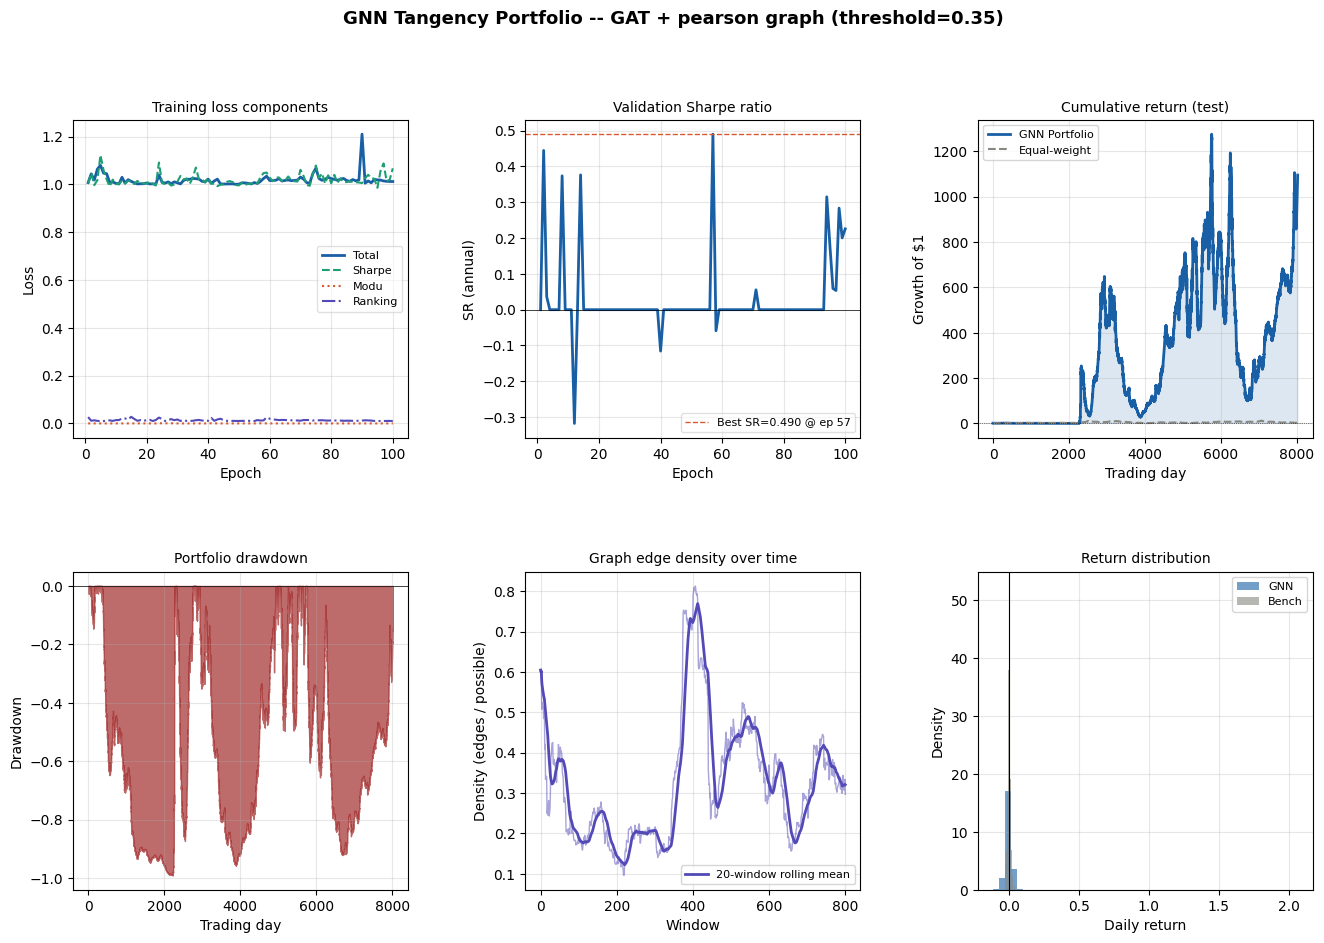

Saved: /content/diagnostics.png


In [ ]:
if __name__ == "__main__":
    log_df, metrics_port, metrics_bench = main()

# SECTION 12.1 - BASELINE MODELS


*   Implements four simple baselines so all models can be compared on the same test period without requiring external data or pre-trained weights.

*   Baselines included:
    *   equal_weight - 1/N allocation across all stocks (simplest benchmark)
    *   momentum - long top-decile, short bottom-decile by 20-day return
    *   min_variance - minimum variance portfolio via sample covariance
    *   ols_factor - OLS multi-factor linear model (closest to paper Fama-3)
  

# SECTION 12.2 - MULTI-MODEL COMPARISON
* Trains all three GNN architectures (GCN, SAGE, GAT) on the same data, runs all four baselines, and collects returns for comparison plotting.

* Returns a dict mapping model name -> list of daily test-period returns. All return series are aligned to the same test window so cumulative return curves can be plotted on the same axes.

# SECTION 12.3 - COMPARISON PLOTS
 * Computes the full metric set for one return series. Returns a dict with all metrics annualised.
* Three publication-quality figures:
    *   cumulative_returns.png  - all models on one chart + benchmark
    *   metrics_comparison.png - bar charts for SR, return, vol, MDD
    *   rolling_sharpe.png    - 63-day rolling SR for each model

* **Figure 1:** Cumulative return curves for every model on one chart.
    * GNN models are drawn with thick solid lines.
    * Baselines are drawn with thin dashed lines.
    * The equal-weight benchmark is highlighted in grey.
* **Figure 2:** Side-by-side bar charts for all evaluation metrics.
    * Panels: Sharpe ratio, annualised return, volatility, max drawdown, Calmar ratio, win rate, skewness, kurtosis.
* **Figure 3:** 63-day rolling Sharpe ratio for every model. Shows which models are consistent vs which have regime-specific performance.
    * GNN models are highlighted with thicker lines.


In [ ]:
def run_baseline(name, R_test, train_len=40, val_len=10):

    T, N = R_test.shape
    port_rets = []

    for idx in range(T - train_len - val_len + 1):
        # Training window returns
        window = R_test[idx : idx + train_len]
        fwd    = R_test[idx + train_len :
                        idx + train_len + val_len]

        if name == "equal_weight":
            w = np.ones(N) / N

        elif name == "momentum":
            # Rank stocks by 20-day cumulative return long top 20%, short bottom 20%
            cum_ret = window.sum(axis=0)
            ranks   = cum_ret.argsort()
            n_dec   = max(1, N // 5)
            w       = np.zeros(N)
            w[ranks[-n_dec:]] =  1.0 / n_dec            # long top
            w[ranks[:n_dec]]  = -1.0 / n_dec            # short bottom

        elif name == "min_variance":
            # Uses sample covariance with a small shrinkage term for stability
            cov = np.cov(window.T)
            cov += np.eye(N) * 1e-4
            try:
                inv_cov = np.linalg.inv(cov)
                ones    = np.ones(N)
                w_raw   = inv_cov @ ones
                w       = w_raw / (ones @ w_raw)
            except np.linalg.LinAlgError:
                w = np.ones(N) / N

        elif name == "ols_factor":
            # OLS linear factor model: predict next-period returns using
            # lagged 1d, 5d, 20d returns as factors.
            features = np.column_stack([
                window[:, :].mean(axis=1),
                np.abs(window).mean(axis=1),
            ])

            X_reg = np.column_stack([np.ones(train_len), features])
            betas = np.linalg.lstsq(X_reg, window, rcond=None)[0]
            # Use last window row as prediction features
            x_last = np.array([1.0, features[-1, 0], features[-1, 1]])
            mu_pred = x_last @ betas                    # (N,) predicted returns
            # Long-short on predicted returns
            ranks   = mu_pred.argsort()
            n_dec   = max(1, N // 5)
            w       = np.zeros(N)
            w[ranks[-n_dec:]] =  1.0 / n_dec
            w[ranks[:n_dec]]  = -1.0 / n_dec

        else:
            raise ValueError(f"Unknown baseline: {name}")

        # Compute portfolio return for each day in the forward window
        # w shape (N,)  fwd shape (10, N)
        daily = fwd @ w
        port_rets.extend(daily.tolist())

    return port_rets


# =============================================================================
# SECTION 12.2 - MULTI-MODEL COMPARISON
# =============================================================================

def run_all_models(close_df, volume_df, R, X, device):

    T = X.shape[0]
    N = close_df.shape[1]

    test_size  = int(T * CFG["test_split"])
    train_size = T - test_size

    X_train, R_train = X[:train_size],  R[:train_size]
    X_test,  R_test  = X[train_size:],  R[train_size:]

    test_start = close_df.index[train_size].strftime("%Y-%m-%d")
    test_end   = close_df.index[-1].strftime("%Y-%m-%d")
    print(f"\n  Test period: {test_start} to {test_end}  ({test_size} days)")

    # Pre-build rolling graphs once -- shared across all GNN models
    print("\nPre-building rolling graphs (shared for all GNN models)...")
    graphs_train = precompute_graphs(
        R_train, train_len=CFG["train_len"],
        threshold=CFG["threshold"], method=CFG["graph_method"])
    graphs_test = precompute_graphs(
        R_test, train_len=CFG["train_len"],
        threshold=CFG["threshold"], method=CFG["graph_method"])

    # Datasets
    train_ds = SlidingWindowDataset(
        X_train, R_train, CFG["train_len"], CFG["val_len"])
    test_ds  = SlidingWindowDataset(
        X_test,  R_test,  CFG["train_len"], CFG["val_len"])
    train_loader = DataLoader(
        train_ds, batch_size=CFG["batch_size"],
        shuffle=True,  collate_fn=collate_fn, num_workers=0)
    test_loader  = DataLoader(
        test_ds,  batch_size=CFG["batch_size"],
        shuffle=False, collate_fn=collate_fn, num_workers=0)

    all_results = {}   # model_name -> list of daily returns

    # ----------------------------------------------------------------
    # Train each GNN architecture
    # ----------------------------------------------------------------
    for gnn_type in ["GCN", "SAGE", "GAT"]:
        print(f"\n{'='*55}")
        print(f"  Training {gnn_type} ...")
        print(f"{'='*55}")

        torch.manual_seed(CFG["seed"])
        np.random.seed(CFG["seed"])

        gnn_model = GNNEmbedding(
            in_dim=7,
            hidden_dim=CFG["hidden_dim"],
            out_dim=CFG["embed_dim"],
            num_layers=CFG["num_layers"],
            gnn_type=gnn_type,
            dropout=CFG["dropout"],
            heads=CFG["heads"],
        ).to(device)

        fitter = MeanPrecisionFitter(
            embed_dim=CFG["embed_dim"],
            n_stocks=N,
        ).to(device)

        all_params = (list(gnn_model.parameters())
                      + list(fitter.parameters()))
        optimizer  = torch.optim.Adam(all_params, lr=CFG["lr"])
        warmup_am = CFG["lr_warmup_epochs"]
        def lr_lambda_am(ep):
            if ep < warmup_am:
                return (ep + 1) / warmup_am
            return 0.5 ** ((ep - warmup_am) // 30)
        scheduler = torch.optim.lr_scheduler.LambdaLR(
            optimizer, lr_lambda_am)

        best_val_sr = -np.inf
        best_gnn_sd = None
        best_fit_sd = None

        print(f"  {'Ep':>4}  {'Loss':>8}  {'Val SR':>7}")
        print("  " + "-" * 25)

        for epoch in range(1, CFG["epochs"] + 1):
            gnn_model.train(); fitter.train()
            ep_loss = 0.0; n_batches = 0

            for batch_idx, (x_feat, raw_ret, y_ret, hist_ret) in \
                    enumerate(train_loader):
                x_feat   = x_feat.to(device)
                y_ret    = y_ret.to(device)
                hist_ret = hist_ret.to(device)
                B        = x_feat.shape[0]
                batch_loss = torch.tensor(0.0, device=device)

                for b in range(B):
                    x_mean = x_feat[b].mean(dim=0)
                    win_idx = ((batch_idx * CFG["batch_size"] + b)
                               % len(graphs_train))
                    ei = graphs_train[win_idx].to(device)
                    H                = gnn_model(x_mean, ei)
                    mu_hat, prec_hat = fitter(H)
                    w                = predict_weights(mu_hat, prec_hat)
                    port_rets_b      = y_ret[b] @ w
                    loss, _          = total_loss(
                        port_rets_b, prec_hat, mu_hat, hist_ret[b],
                        alpha1=CFG["alpha1"], alpha2=CFG["alpha2"])
                    batch_loss = batch_loss + loss / B

                optimizer.zero_grad()
                batch_loss.backward()
                nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
                optimizer.step()
                ep_loss   += batch_loss.item()
                n_batches += 1

            scheduler.step()

            # Validation SR
            p_val, _, _, _ = run_inference(
                gnn_model, fitter, test_loader,
                graphs_test, device, CFG["batch_size"])
            arr    = np.array(p_val)
            val_sr = (arr.mean() / (arr.std() + 1e-8)) * (252 ** 0.5)

            if val_sr > best_val_sr:
                best_val_sr = val_sr
                # Store state-dict copies (not references)
                best_gnn_sd = {k: v.clone()
                               for k, v in gnn_model.state_dict().items()}
                best_fit_sd = {k: v.clone()
                               for k, v in fitter.state_dict().items()}

            if epoch % 10 == 0 or epoch == 1:
                print(f"  {epoch:>4}  {ep_loss/max(n_batches,1):>8.4f}"
                      f"  {val_sr:>7.4f}")

        # Load best checkpoint and collect test returns
        gnn_model.load_state_dict(best_gnn_sd)
        fitter.load_state_dict(best_fit_sd)

        port_rets, _, _, _ = run_inference(
            gnn_model, fitter, test_loader,
            graphs_test, device, CFG["batch_size"])

        all_results[f"GNN-{gnn_type}"] = port_rets
        print(f"  Best validation SR ({gnn_type}): {best_val_sr:.4f}")

    # ----------------------------------------------------------------
    # Run baselines on the same test period
    # ----------------------------------------------------------------
    print(f"\n{'='*55}")
    print("  Running baselines ...")
    print(f"{'='*55}")

    baseline_names = {
        "Equal-Weight":   "equal_weight",
        "Momentum":       "momentum",
        "Min-Variance":   "min_variance",
        "OLS-Factor":     "ols_factor",
    }
    for label, name in baseline_names.items():
        rets = run_baseline(
            name, R_test,
            train_len=CFG["train_len"],
            val_len=CFG["val_len"])
        all_results[label] = rets
        arr = np.array(rets)
        sr  = (arr.mean() / (arr.std() + 1e-8)) * (252 ** 0.5)
        print(f"  {label:<20} SR = {sr:.4f}")

    return all_results, R_test


# =============================================================================
# SECTION 12.3 - COMPARISON PLOTS
# =============================================================================

def compute_full_metrics(rets, trading_days=252):

    rets   = np.array(rets)
    mean_r = rets.mean()
    std_r  = rets.std() + 1e-8
    sr     = mean_r / std_r * trading_days ** 0.5
    ann_r  = mean_r * trading_days
    ann_v  = std_r  * trading_days ** 0.5
    cum    = np.cumprod(1 + rets)
    peak   = np.maximum.accumulate(cum)
    mdd    = ((cum - peak) / peak).min()
    calmar = ann_r / abs(mdd) if mdd != 0 else 0.0
    wr     = float((rets > 0).mean())
    skew   = float(pd.Series(rets).skew())
    kurt   = float(pd.Series(rets).kurtosis())
    return {
        "Sharpe (ann)":  round(sr,     4),
        "Return (ann)":  round(ann_r,  4),
        "Volatility":    round(ann_v,  4),
        "Max Drawdown":  round(mdd,    4),
        "Calmar Ratio":  round(calmar, 4),
        "Win Rate":      round(wr,     4),
        "Skewness":      round(skew,   4),
        "Kurtosis":      round(kurt,   4),
        "_cum":          cum.tolist(),
        "_rets":         rets.tolist(),
    }


def plot_cumulative_returns(all_metrics, test_dates=None):
    # Figure 1
    style_map = {
        "GNN-GCN":      (2.2, "-",  "#185FA5"),
        "GNN-SAGE":     (2.2, "-",  "#1D9E75"),
        "GNN-GAT":      (2.8, "-",  "#D85A30"),
        "Equal-Weight": (1.5, "--", "#888780"),
        "Momentum":     (1.2, "--", "#534AB7"),
        "Min-Variance": (1.2, "--", "#BA7517"),
        "OLS-Factor":   (1.2, "--", "#A32D2D"),
    }

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            hspace=0.40, wspace=0.30)

    # ---- Panel 1: all cumulative returns ----
    ax1 = fig.add_subplot(gs[0, :])  # full top row

    for name, metrics in all_metrics.items():
        cum  = np.array(metrics["_cum"])
        lw, ls, color = style_map.get(name, (1.2, "--", "#888888"))
        ax1.plot(cum, label=name, lw=lw, ls=ls, color=color)

    ax1.axhline(1, color="black", lw=0.6, ls=":")
    ax1.set_title("Cumulative Return -- All Models vs Baselines (Test Period)",
                  fontsize=11, fontweight="bold")
    ax1.set_xlabel("Trading day (test period)")
    ax1.set_ylabel("Growth of $1 invested")
    ax1.legend(fontsize=8.5, framealpha=0.8,
               ncol=2, loc="upper left")
    ax1.grid(True, alpha=0.25)

    # ---- Panel 2: GNN models only (zoomed) ----
    ax2 = fig.add_subplot(gs[1, 0])
    for name in ["GNN-GCN", "GNN-SAGE", "GNN-GAT"]:
        if name not in all_metrics:
            continue
        cum   = np.array(all_metrics[name]["_cum"])
        lw, ls, color = style_map[name]
        sr    = all_metrics[name]["Sharpe (ann)"]
        ax2.plot(cum, label=f"{name}  SR={sr:.3f}",
                 lw=lw, ls=ls, color=color)

    ax2.axhline(1, color="black", lw=0.6, ls=":")
    # Shade under GAT if present
    if "GNN-GAT" in all_metrics:
        gat_cum = np.array(all_metrics["GNN-GAT"]["_cum"])
        ax2.fill_between(range(len(gat_cum)), 1, gat_cum,
                         where=gat_cum >= 1, alpha=0.10,
                         color="#D85A30")
        ax2.fill_between(range(len(gat_cum)), 1, gat_cum,
                         where=gat_cum < 1,  alpha=0.10,
                         color="#A32D2D")
    ax2.set_title("GNN Models (zoomed)", fontsize=10,
                  fontweight="bold")
    ax2.set_xlabel("Trading day"); ax2.set_ylabel("Growth of $1")
    ax2.legend(fontsize=8, framealpha=0.8)
    ax2.grid(True, alpha=0.25)

    # ---- Panel 3: Drawdown for each model ----
    ax3 = fig.add_subplot(gs[1, 1])
    for name, metrics in all_metrics.items():
        cum  = np.array(metrics["_cum"])
        peak = np.maximum.accumulate(cum)
        dd   = (cum - peak) / peak
        lw, ls, color = style_map.get(name, (1.0, "--", "#888888"))
        ax3.plot(dd, lw=lw * 0.8, ls=ls, color=color,
                 label=name, alpha=0.85)

    ax3.axhline(0, color="black", lw=0.5)
    ax3.set_title("Drawdown -- All Models", fontsize=10,
                  fontweight="bold")
    ax3.set_xlabel("Trading day"); ax3.set_ylabel("Drawdown")
    ax3.legend(fontsize=7.5, framealpha=0.8, ncol=2)
    ax3.grid(True, alpha=0.25)

    fig.suptitle("Figure A: Cumulative Returns and Drawdowns",
                 fontsize=12, fontweight="bold", y=1.01)

    plt.savefig("/content/cumulative_returns.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/cumulative_returns.png")


def plot_metrics_comparison(all_metrics):
    # figure 2

    metric_keys = [
        ("Sharpe (ann)",  "Sharpe Ratio\n(annualised)", True),
        ("Return (ann)",  "Return\n(annualised)",        True),
        ("Volatility",    "Volatility\n(annualised)",    False),
        ("Max Drawdown",  "Max Drawdown",                False),
        ("Calmar Ratio",  "Calmar Ratio",                True),
        ("Win Rate",      "Win Rate",                    True),
        ("Skewness",      "Return Skewness",             True),
        ("Kurtosis",      "Excess Kurtosis",             False),
    ]

    names = list(all_metrics.keys())
    # Colour: dark blue for GNN, muted for baselines
    bar_colors = []
    gnn_palette = {"GNN-GCN": "#185FA5", "GNN-SAGE": "#1D9E75",
                   "GNN-GAT": "#D85A30"}
    base_palette = {"Equal-Weight": "#B0AEA8", "Momentum": "#C0B8EC",
                    "Min-Variance": "#F0D090", "OLS-Factor": "#F0A898"}
    for n in names:
        bar_colors.append(gnn_palette.get(n, base_palette.get(n, "#AAAAAA")))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.patch.set_facecolor("white")

    for ax, (key, label, higher_better) in \
            zip(axes.flat, metric_keys):
        vals = [all_metrics[n][key] for n in names]

        # Highlight the best bar
        best_idx = (np.argmax(vals) if higher_better
                    else np.argmin(vals))

        bar_objs = ax.bar(range(len(names)), vals,
                          color=bar_colors, alpha=0.85,
                          edgecolor="white", linewidth=0.6)

        # Gold border on best bar
        bar_objs[best_idx].set_edgecolor("#BA7517")
        bar_objs[best_idx].set_linewidth(2.0)

        # Value labels on bars
        for i, (bar, val) in enumerate(zip(bar_objs, vals)):
            y_off = max(abs(val) * 0.04, 0.002)
            va    = "bottom" if val >= 0 else "top"
            y_pos = val + y_off if val >= 0 else val - y_off
            ax.text(bar.get_x() + bar.get_width() / 2,
                    y_pos, f"{val:.3f}",
                    ha="center", va=va,
                    fontsize=7.5, color="#2B2A27")

        ax.axhline(0, color="black", lw=0.6)
        ax.set_title(label, fontsize=9.5, fontweight="bold")
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=35, ha="right",
                           fontsize=7.5)
        ax.grid(True, alpha=0.2, axis="y")

        # Arrow indicating which direction is better
        direction = "higher is better" if higher_better \
                    else "lower is better"
        ax.text(0.98, 0.97, direction,
                transform=ax.transAxes,
                fontsize=6.5, color="#888780",
                ha="right", va="top", style="italic")

    # Legend for model type
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="#185FA5", label="GNN-GCN"),
        Patch(facecolor="#1D9E75", label="GNN-SAGE"),
        Patch(facecolor="#D85A30", label="GNN-GAT"),
        Patch(facecolor="#B0AEA8", label="Baselines"),
    ]
    fig.legend(handles=legend_handles,
               loc="lower center", ncol=4,
               fontsize=9, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(
        "Figure B: Full Evaluation Metrics -- All Models vs Baselines\n"
        "(gold border = best in class per metric)",
        fontsize=12, fontweight="bold", y=1.01)

    plt.tight_layout()
    plt.savefig("/content/metrics_comparison.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/metrics_comparison.png")


def plot_rolling_sharpe(all_metrics, window=63):
    # Figure 3
    style_map = {
        "GNN-GCN":      (2.0, "-",  "#185FA5"),
        "GNN-SAGE":     (2.0, "-",  "#1D9E75"),
        "GNN-GAT":      (2.5, "-",  "#D85A30"),
        "Equal-Weight": (1.2, "--", "#888780"),
        "Momentum":     (1.0, "--", "#534AB7"),
        "Min-Variance": (1.0, "--", "#BA7517"),
        "OLS-Factor":   (1.0, "--", "#A32D2D"),
    }

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                   sharex=False)
    fig.patch.set_facecolor("white")

    # ---- Panel 1: all models ----
    for name, metrics in all_metrics.items():
        rets = np.array(metrics["_rets"])
        rs   = [rets[max(0, i - window):i].mean() /
                (rets[max(0, i - window):i].std() + 1e-8) * 252 ** 0.5
                for i in range(window, len(rets))]
        lw, ls, color = style_map.get(name, (1.0, "--", "#888888"))
        ax1.plot(rs, label=name, lw=lw, ls=ls,
                 color=color, alpha=0.9)

    ax1.axhline(0, color="black", lw=0.7)
    ax1.fill_between(range(len(rs)), 0, 0,
                     alpha=0)   # dummy for legend spacing
    ax1.set_title(
        f"Rolling Sharpe Ratio ({window}-day window) -- All Models",
        fontsize=10, fontweight="bold")
    ax1.set_ylabel("Sharpe Ratio (annualised)")
    ax1.legend(fontsize=8.5, framealpha=0.8, ncol=2)
    ax1.grid(True, alpha=0.25)

    # ---- Panel 2: GNN models only with fill ----
    for name in ["GNN-GCN", "GNN-SAGE", "GNN-GAT"]:
        if name not in all_metrics:
            continue
        rets = np.array(all_metrics[name]["_rets"])
        rs   = np.array([
            rets[max(0, i - window):i].mean() /
            (rets[max(0, i - window):i].std() + 1e-8) * 252 ** 0.5
            for i in range(window, len(rets))])
        lw, ls, color = style_map[name]
        sr_ann = all_metrics[name]["Sharpe (ann)"]
        ax2.plot(rs, label=f"{name}  SR={sr_ann:.3f}",
                 lw=lw, ls=ls, color=color)
        ax2.fill_between(range(len(rs)), 0, rs,
                         where=rs >= 0, alpha=0.10, color=color)
        ax2.fill_between(range(len(rs)), 0, rs,
                         where=rs < 0,  alpha=0.08, color="#A32D2D")

    ax2.axhline(0, color="black", lw=0.7)
    ax2.set_title("GNN Models -- Rolling Sharpe (zoomed)",
                  fontsize=10, fontweight="bold")
    ax2.set_xlabel(f"Trading day offset (from day {window})")
    ax2.set_ylabel("Sharpe Ratio (annualised)")
    ax2.legend(fontsize=8.5, framealpha=0.8)
    ax2.grid(True, alpha=0.25)

    fig.suptitle(
        f"Figure C: {window}-Day Rolling Sharpe Ratio\n"
        "Reveals consistency of risk-adjusted performance across market regimes",
        fontsize=12, fontweight="bold", y=1.01)

    plt.tight_layout()
    plt.savefig("/content/rolling_sharpe.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/rolling_sharpe.png")


def print_metrics_table(all_metrics):
    """
    Prints a clean aligned metrics table to the console and saves it
    as a CSV to /content/all_model_metrics.csv.
    """
    metric_keys = ["Sharpe (ann)", "Return (ann)", "Volatility",
                   "Max Drawdown", "Calmar Ratio", "Win Rate",
                   "Skewness", "Kurtosis"]

    # Console header
    header = f"{'Model':<20}" + "".join(f"{k:>14}" for k in metric_keys)
    print(f"\n{'='*len(header)}")
    print("  FULL MODEL COMPARISON")
    print(f"{'='*len(header)}")
    print(header)
    print("-" * len(header))

    rows = []
    for name, metrics in all_metrics.items():
        row_vals = [metrics[k] for k in metric_keys]
        row_str  = f"{name:<20}" + "".join(f"{v:>14.4f}" for v in row_vals)
        # Mark GNN models with an asterisk
        marker = " *" if name.startswith("GNN") else "  "
        print(marker + row_str)
        rows.append({"Model": name, **{k: metrics[k] for k in metric_keys}})

    print("-" * len(header))
    print("  * = GNN extension model")
    print(f"{'='*len(header)}\n")

    # Save CSV
    df = pd.DataFrame(rows)
    df.to_csv("/content/all_model_metrics.csv", index=False)
    print("Saved: /content/all_model_metrics.csv")
    return df


# =============================================================================
# RUN
# =============================================================================

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # OPTION A: Run the single configured model only (original behaviour)
    # Comment out OPTION B below if you only want one model.
    # ------------------------------------------------------------------
    # log_df, metrics_port, metrics_bench = main()

    # ------------------------------------------------------------------
    # OPTION B: Run all three GNN architectures + four baselines,
    # then produce the full comparison figures.
    # This takes longer (~3x the single-model time) but gives you
    # all the comparison plots for the paper.
    # ------------------------------------------------------------------

    torch.manual_seed(CFG["seed"])
    np.random.seed(CFG["seed"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")
    print("Running OPTION B: all models + baselines comparison\n")

    # Step 1: load data and build features (shared for all models)
    close_df, volume_df = load_or_download(
        TICKERS, start=CFG["start"], end=CFG["end"])
    N = close_df.shape[1]
    print(f"  Stocks: {N}   Days: {len(close_df)}")

    print("\nBuilding features...")
    X = build_features(close_df, volume_df)
    R = close_df.pct_change().fillna(0).values.astype(np.float32)

    # Step 2: train all GNN models + run baselines
    all_results, R_test = run_all_models(
        close_df, volume_df, R, X, device)

    # Step 3: compute full metrics for every model
    print("\nComputing metrics for all models...")
    all_metrics = {}
    for name, rets in all_results.items():
        all_metrics[name] = compute_full_metrics(rets)

    # Step 4: print the comparison table + save CSV
    metrics_df = print_metrics_table(all_metrics)

    # Step 5: produce all three comparison figures
    print("\nGenerating comparison figures...")
    try:
        import matplotlib
        matplotlib.use("Agg")   # remove this line in Colab (not needed)
        plot_cumulative_returns(all_metrics)
        plot_metrics_comparison(all_metrics)
        plot_rolling_sharpe(all_metrics, window=63)
        print("\nAll figures saved to /content/")
    except ImportError:
        print("matplotlib not installed -- skipping figures")

    # Step 6: save full results JSON
    save_dict = {
        name: {k: v for k, v in m.items()
               if not k.startswith("_")}   # exclude raw series
        for name, m in all_metrics.items()
    }
    with open("/content/all_model_results.json", "w") as f:
        json.dump(save_dict, f, indent=2)
    print("Saved: /content/all_model_results.json")



Device: cuda
Running OPTION B: all models + baselines comparison



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Saved 5679 days x 94 stocks to /content/prices.csv
  Stocks: 94   Days: 5679

Building features...

  Test period: 2020-07-02 to 2023-12-28  (851 days)

Pre-building rolling graphs (shared for all GNN models)...
  Building 4789 rolling graphs (method=pearson, threshold=0.35)...
    200/4789 graphs built
    400/4789 graphs built
    600/4789 graphs built
    800/4789 graphs built
    1000/4789 graphs built
    1200/4789 graphs built
    1400/4789 graphs built
    1600/4789 graphs built
    1800/4789 graphs built
    2000/4789 graphs built
    2200/4789 graphs built
    2400/4789 graphs built
    2600/4789 graphs built
    2800/4789 graphs built
    3000/4789 graphs built
    3200/4789 graphs built
    3400/4789 graphs built
    3600/4789 graphs built
    3800/4789 graphs built
    4000/4789 graphs built
    4200/4789 graphs built
    4400/4789 graphs built
    4600/4789 graphs built
  Done. Average edges per graph: 4486.9
  Building 812 rolling graphs (method=pearson, threshold=0.35)..

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
